Puntaje del conjunto de entrenamiento: 0.839789
Puntaje del conjunto de prueba: 0.813380


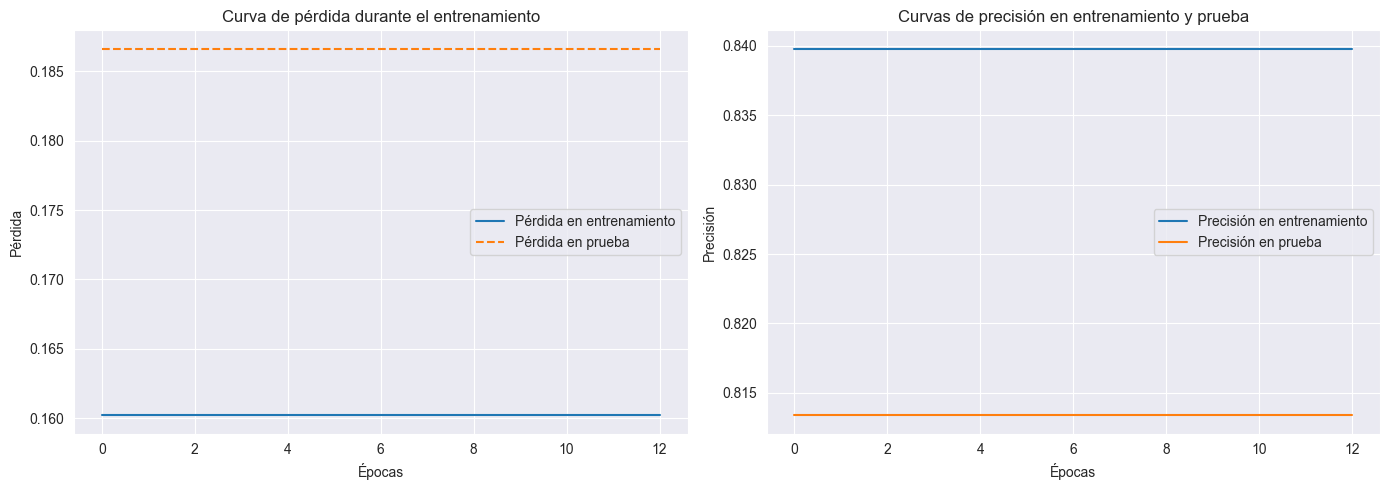

Train Accuracy: 0.8398
Test Accuracy: 0.8134


In [95]:
from src.data.data_transformer import convert_columns_values_to_numeric, remove_outliers_percentile, normalize_input
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt

# Cargar y preprocesar los datos
data = pd.read_csv('../data/raw/spotify_most_streamed_songs.csv', delimiter=",")
# Convierto todos los datos a valores numericos
data = convert_columns_values_to_numeric(pd, data, data.select_dtypes(include='object').columns)

# Elimino todas las columnas que contengas datos NaN
data = data.dropna(axis=1, how='all')

# Estos fueron a mano porque contenian al menos un dato numerico.
data = data.drop(['track_name', 'instrumentalness_%'], axis=1)

# Cambio los valores de la columna 'streams' a 0 o 1 según si pasa el umbral de 100 millones
data['streams'] = data['streams'].apply(lambda x: 1 if x > 100_000_000 else 0)

# Tomo las columnas relevantes (segun matriz de correlacion)
relevant_columns = data[["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"]]

# Normalizo las columnas de entrada.
relevant_columns = normalize_input(relevant_columns)

"""# Grafico la distribucion de los datos
data_distribution(relevant_columns, "in_spotify_playlists")
data_distribution(relevant_columns, "in_apple_playlists")
data_distribution(relevant_columns, "in_deezer_playlists")"""

# Elimino los valores atípicos usando la técnica de percentile ya que mis datos tienen una fuerte asimetria hacia la derecha
data = remove_outliers_percentile(data, relevant_columns)

relevant_columns = data[["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"]]

"""# Grafico la distribucion de los datos
data_distribution(relevant_columns, "in_spotify_playlists")
data_distribution(relevant_columns, "in_apple_playlists")
data_distribution(relevant_columns, "in_deezer_playlists")"""

# Datos de entrada
all_inputs = relevant_columns.values

# Datos de salida
all_outputs = data[["streams"]].values

# División de los datos en entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(all_inputs, all_outputs, test_size=1/3, random_state=42)

# Configurar la red neuronal con MLPClassifier
model = MLPClassifier(
    hidden_layer_sizes=(8,),     # Capa oculta con 8 neuronas
    activation='relu',           # Función de activación ReLU
    solver='sgd',               # Optimizador
    alpha=0.001,                # Regularización L2 (lambda)
    learning_rate_init=0.01,    # Tasa de aprendizaje inicial
    max_iter=3000,               # Número máximo de épocas
    random_state=42
)

Y_train = Y_train.ravel()
Y_test = Y_test.ravel()

# Entrenar el modelo
model.fit(X_train, Y_train)

print("Puntaje del conjunto de entrenamiento: %f" % model.score(X_train, Y_train))
print("Puntaje del conjunto de prueba: %f" % model.score(X_test, Y_test))

# Guardar la curva de pérdida y calcular precisión por época
loss_values = model.loss_curve_

# Listas para almacenar la precisión en cada época
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []

# Evaluar el modelo en cada época utilizando la función partial_fit
for i in range(1, len(loss_values) + 1):
    model.partial_fit(X_train, Y_train, classes=[0, 1])  # Continuar ajustando en cada época
    
    # Calcular precisión y pérdida en el conjunto de entrenamiento
    train_preds = model.predict(X_train)
    train_accuracy = accuracy_score(Y_train, train_preds)
    train_loss = mean_squared_error(Y_train, train_preds)
    
    # Calcular precisión y pérdida en el conjunto de prueba
    test_preds = model.predict(X_test)
    test_accuracy = accuracy_score(Y_test, test_preds)
    test_loss = mean_squared_error(Y_test, test_preds)
    
    # Guardar los resultados
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    

# Graficar la pérdida y precisión
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Pérdida en entrenamiento')
plt.plot(test_losses, label='Pérdida en prueba', linestyle='--')
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida durante el entrenamiento")
plt.legend()

# Gráfico de Precisión
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Precisión en entrenamiento')
plt.plot(test_accuracies, label='Precisión en prueba')
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.title("Curvas de precisión en entrenamiento y prueba")
plt.legend()

plt.tight_layout()
plt.show()

# Precisión final
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Test Accuracy: {test_accuracies[-1]:.4f}")
